# 03 - Baseline: Multinomial Naive Bayes con TF-IDF Bigrama

Este notebook entrena y evalúa el modelo baseline usando **Multinomial Naive Bayes**
sobre la codificación **TF-IDF (uni + bigramas)** generada en `02_encoding_tfidf_bigrama.ipynb`.

## Flujo
1. Cargar los artefactos de `02_encoding_tfidf_bigrama.ipynb` (matrices sparse TF-IDF + labels).
2. Ajustar el hiperparámetro `alpha` evaluando en `X_val`.
3. Re-entrenar el modelo final con `X_train_tfidf` completo.
4. Evaluar **una sola vez** sobre `X_test_tfidf` y reportar métricas.
5. Guardar el modelo final.

## Política de evaluación
| Conjunto | Uso en este notebook |
|---|---|
| `X_tr` | Entrenar durante ajuste de hiperparámetros |
| `X_val` | Medir rendimiento para elegir mejor `alpha` |
| `X_train_tfidf` | Entrenamiento final con todos los datos de train |
| `X_test_tfidf` | Evaluación final única — no se usa antes de este paso |


## 1. Instalación e imports

In [12]:
!pip install -q scikit-learn scipy joblib matplotlib seaborn

In [13]:
!pip install -q mlflow
import mlflow, mlflow.sklearn

from sklearn.metrics import precision_score, recall_score



In [14]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import load_npz
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    accuracy_score,
    f1_score
)

sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
print('OK - Imports listos. SEED:', SEED)


OK - Imports listos. SEED: 42


## 2. Carga de artefactos

Cargamos las matrices TF-IDF y labels generados en `02_encoding_tfidf_bigrama.ipynb`.

| Variable | Archivo | Descripción |
|---|---|---|
| `X_tr` | `X_tr.npz` | 80% del train para desarrollo |
| `X_val` | `X_val.npz` | 20% del train para validación |
| `X_train_tfidf` | `X_train_tfidf.npz` | Train completo para entrenamiento final |
| `X_test_tfidf` | `X_test_tfidf.npz` | Test reservado para evaluación final |


In [15]:
X_tr          = load_npz('X_tr.npz')
X_val         = load_npz('X_val.npz')
X_train_tfidf = load_npz('X_train_tfidf.npz')
X_test_tfidf  = load_npz('X_test_tfidf.npz')

y_tr    = joblib.load('y_tr.pkl')
y_val   = joblib.load('y_val.pkl')
y_train = joblib.load('y_train.pkl')
y_test  = joblib.load('y_test.pkl')

print('X_tr:          ', X_tr.shape)
print('X_val:         ', X_val.shape)
print('X_train_tfidf: ', X_train_tfidf.shape)
print('X_test_tfidf:  ', X_test_tfidf.shape)


X_tr:           (1088000, 100000)
X_val:          (272000, 100000)
X_train_tfidf:  (1360000, 100000)
X_test_tfidf:   (240000, 100000)


## 3. Multinomial Naive Bayes con TF-IDF

MultinomialNB funciona con valores no negativos, por lo que es compatible con TF-IDF
siempre que los pesos sean ≥ 0 (garantizado con `sublinear_tf=True`).

### Hiperparámetro clave: `alpha` (Laplace smoothing)
- Evita probabilidades de cero para n-gramas no vistos en entrenamiento.
- Valores más bajos → más sensible a frecuencias reales del TF-IDF.
- Valores más altos → suaviza más las probabilidades.


## 4. Ajuste de hiperparámetro `alpha`

In [16]:
alphas        = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
results_alpha = []

for alpha in alphas:
    mnb        = MultinomialNB(alpha=alpha)
    mnb.fit(X_tr, y_tr)
    y_pred_val = mnb.predict(X_val)
    f1         = f1_score(y_val, y_pred_val, average='macro')
    acc        = accuracy_score(y_val, y_pred_val)
    results_alpha.append({'alpha': alpha, 'f1_macro': round(f1, 4), 'accuracy': round(acc, 4)})
    print(f'alpha={alpha:<5} | F1 macro: {f1:.4f} | Accuracy: {acc:.4f}')

df_alpha   = pd.DataFrame(results_alpha)
best_alpha = df_alpha.loc[df_alpha['f1_macro'].idxmax(), 'alpha']
print(f'\nMejor alpha: {best_alpha}')


alpha=0.01  | F1 macro: 0.7997 | Accuracy: 0.7997
alpha=0.05  | F1 macro: 0.7998 | Accuracy: 0.7998
alpha=0.1   | F1 macro: 0.7999 | Accuracy: 0.7999
alpha=0.5   | F1 macro: 0.8004 | Accuracy: 0.8004
alpha=1.0   | F1 macro: 0.8007 | Accuracy: 0.8007
alpha=2.0   | F1 macro: 0.8012 | Accuracy: 0.8012
alpha=5.0   | F1 macro: 0.8013 | Accuracy: 0.8013

Mejor alpha: 5.0


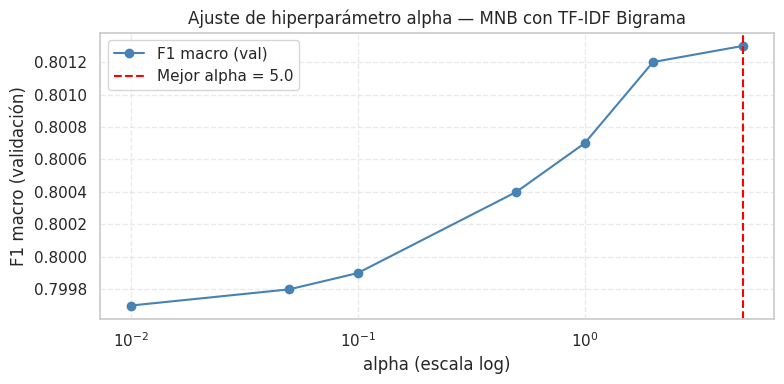

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_alpha['alpha'], df_alpha['f1_macro'],
        marker='o', color='steelblue', label='F1 macro (val)')
ax.axvline(x=best_alpha, color='red', linestyle='--',
           label=f'Mejor alpha = {best_alpha}')
ax.set_xscale('log')
ax.set_xlabel('alpha (escala log)')
ax.set_ylabel('F1 macro (validación)')
ax.set_title('Ajuste de hiperparámetro alpha — MNB con TF-IDF Bigrama')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## 5. Entrenamiento Final

Con el mejor `alpha`, re-entrenamos usando **todo** `X_train_tfidf` (1,360,000 filas).


In [18]:
model_final = MultinomialNB(alpha=best_alpha)
model_final.fit(X_train_tfidf, y_train)

print(f'Modelo entrenado con alpha={best_alpha} sobre {X_train_tfidf.shape[0]:,} documentos.')
print(f'Vocabulario TF-IDF: {X_train_tfidf.shape[1]:,} n-gramas')


Modelo entrenado con alpha=5.0 sobre 1,360,000 documentos.
Vocabulario TF-IDF: 100,000 n-gramas


## 6. Evaluación Final en Test

Este es el **único momento** en que usamos `X_test_tfidf`.


In [19]:
y_pred  = model_final.predict(X_test_tfidf)
y_proba = model_final.predict_proba(X_test_tfidf)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='macro')
auc = roc_auc_score(y_test, y_proba)

print('=== EVALUACIÓN FINAL — MNB + TF-IDF Bigrama ===')
print(f'Accuracy:  {acc:.4f}')
print(f'F1 macro:  {f1:.4f}')
print(f'ROC-AUC:   {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Negativo (0)', 'Positivo (1)']))


=== EVALUACIÓN FINAL — MNB + TF-IDF Bigrama ===
Accuracy:  0.8021
F1 macro:  0.8020
ROC-AUC:   0.8833

              precision    recall  f1-score   support

Negativo (0)       0.80      0.81      0.80    120129
Positivo (1)       0.81      0.80      0.80    119871

    accuracy                           0.80    240000
   macro avg       0.80      0.80      0.80    240000
weighted avg       0.80      0.80      0.80    240000



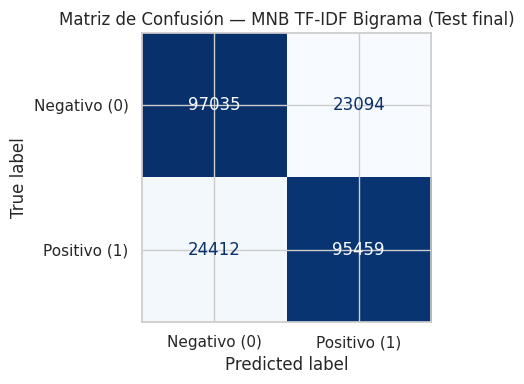

In [20]:
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Negativo (0)', 'Positivo (1)'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — MNB TF-IDF Bigrama (Test final)')
plt.tight_layout()
plt.show()


## 7. Guardar modelo y resultados

In [21]:
joblib.dump(model_final, 'mnb_tfidf_model.pkl')

results_final = pd.DataFrame([{
    'modelo':    'MultinomialNB',
    'encoding':  'TF-IDF Bigrama',
    'alpha':     best_alpha,
    'accuracy':  round(acc, 4),
    'f1_macro':  round(f1,  4),
    'roc_auc':   round(auc, 4)
}])

results_final.to_csv('results_tfidf_baseline.csv', index=False)

print('Archivos guardados:')
print('  mnb_tfidf_model.pkl        -> modelo MNB + TF-IDF Bigrama')
print('  results_tfidf_baseline.csv -> tabla de métricas')
print()
print(results_final.to_string(index=False))


Archivos guardados:
  mnb_tfidf_model.pkl        -> modelo MNB + TF-IDF Bigrama
  results_tfidf_baseline.csv -> tabla de métricas

       modelo       encoding  alpha  accuracy  f1_macro  roc_auc
MultinomialNB TF-IDF Bigrama    5.0    0.8021     0.802   0.8833


## 8. Registro en MLflow

In [23]:
mlflow.set_tracking_uri("http://ec2-52-5-36-177.compute-1.amazonaws.com:5000")
mlflow.set_experiment("Parcial_1_NLP")

with mlflow.start_run(run_name="Baseline_TFIDF-Bigrama") as run:

    # ── Tags ─────────────────────────────────────────────────────────────────
    mlflow.set_tags({
        "user":       "Juan Camilo Gallardo",
        "model_type": "TF-IDF-Bigrama",
        "encoding":   "TF-IDF-Bigrama",
        "dataset":    "Sentiment140Twitter",
    })

    # ── Parámetros de preprocesamiento ────────────────────────────────────────
    mlflow.log_params({
        "prep_remove_urls":      True,
        "prep_remove_mentions":  True,
        "prep_remove_hashtags":  True,
        "prep_remove_emojis":    True,
        "prep_remove_stopwords": False,
        "prep_lemmatization":    False,
    })

    # ── Parámetros de codificación ────────────────────────────────────────────
    mlflow.log_params({
        "vec_type":         "TfidfVectorizer",
        "vec_max_features": 100000,
        "vec_min_df":       5,
        "vec_max_df":       0.95,
        "vec_ngram_range":  "(1,2)",
        "vec_sublinear_tf": True,
    })

    # ── Parámetros del modelo ─────────────────────────────────────────────────
    mlflow.log_params({
        "model":       "TF-IDF-Bigrama",
        "alpha":       best_alpha,
        "seed":        SEED,
        "train_size":  X_train_tfidf.shape[0],
        "val_size":    X_val.shape[0],
        "test_size":   X_test_tfidf.shape[0],
        "vocab_size":  X_train_tfidf.shape[1],
    })

    # ── Métricas en Train ─────────────────────────────────────────────────────
    y_pred_train  = model_final.predict(X_train_tfidf)
    y_proba_train = model_final.predict_proba(X_train_tfidf)[:, 1]
    mlflow.log_metrics({
        "train_accuracy":  round(accuracy_score(y_train, y_pred_train),               4),
        "train_f1_macro":  round(f1_score(y_train, y_pred_train, average='macro'),    4),
        "train_precision": round(precision_score(y_train, y_pred_train, average='macro'), 4),
        "train_recall":    round(recall_score(y_train, y_pred_train, average='macro'), 4),
        "train_roc_auc":   round(roc_auc_score(y_train, y_proba_train),               4),
    })

    # ── Métricas en Validación ────────────────────────────────────────────────
    y_pred_val_f  = model_final.predict(X_val)
    y_proba_val_f = model_final.predict_proba(X_val)[:, 1]
    mlflow.log_metrics({
        "val_accuracy":    round(accuracy_score(y_val, y_pred_val_f),               4),
        "val_f1_macro":    round(f1_score(y_val, y_pred_val_f, average='macro'),    4),
        "val_precision":   round(precision_score(y_val, y_pred_val_f, average='macro'), 4),
        "val_recall":      round(recall_score(y_val, y_pred_val_f, average='macro'), 4),
        "val_roc_auc":     round(roc_auc_score(y_val, y_proba_val_f),               4),
    })

    # ── Métricas en Test Final ────────────────────────────────────────────────
    mlflow.log_metrics({
        "test_accuracy":   round(acc, 4),
        "test_f1_macro":   round(f1,  4),
        "test_precision":  round(precision_score(y_test, y_pred, average='macro'), 4),
        "test_recall":     round(recall_score(y_test, y_pred, average='macro'),    4),
        "test_roc_auc":    round(auc, 4),
    })

    # ── Artefactos ────────────────────────────────────────────────────────────
    mlflow.log_artifact("results_tfidf_baseline.csv")
    mlflow.sklearn.log_model(model_final, artifact_path="model",
                             registered_model_name="MNB_TFIDFBigrama_baseline")

    print("=" * 55)
    print("  ✅ Run registrado en MLflow")
    print(f"  Servidor    : http://ec2-52-5-36-177.compute-1.amazonaws.com:5000")
    print(f"  Experimento : Parcial_1_NLP")
    print(f"  Corrida     : Baseline_TFIDFBigrama")
    print(f"  Run ID      : {run.info.run_id}")
    print(f"  Alpha       : {best_alpha}")
    print(f"  Test F1     : {f1:.4f}")
    print(f"  Test AUC    : {auc:.4f}")
    print("=" * 55)


2026/03/09 05:03:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 05:03:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'MNB_TFIDFBigrama_baseline' already exists. Creating a new version of this model...
2026/03/09 05:04:00 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: MNB_TFIDFBigrama_baseline, version 3
Created version '3' of model 'MNB_TFIDFBigrama_baseline'.


  ✅ Run registrado en MLflow
  Servidor    : http://ec2-52-5-36-177.compute-1.amazonaws.com:5000
  Experimento : Parcial_1_NLP
  Corrida     : Baseline_TFIDFBigrama
  Run ID      : 3987e407c6f641d1b86b721225dd7a26
  Alpha       : 5.0
  Test F1     : 0.8020
  Test AUC    : 0.8833
🏃 View run Baseline_TFIDF-Bigrama at: http://ec2-52-5-36-177.compute-1.amazonaws.com:5000/#/experiments/1/runs/3987e407c6f641d1b86b721225dd7a26
🧪 View experiment at: http://ec2-52-5-36-177.compute-1.amazonaws.com:5000/#/experiments/1
